# Breast Cancer Ultrasound Classification using Vision Transformer (ViT)

This notebook implements a Vision Transformer-based classifier for breast cancer ultrasound images from the BUSBRA dataset.

**Requirements:**
- Uses Vision Transformer (ViT) - NO CNN
- High accuracy metrics
- Automatic output generation on input
- Benchmark dataset evaluation

## Google Colab Setup Instructions

1. **Enable GPU**: Go to Runtime → Change runtime type → Select GPU (T4)
2. **Upload Dataset**: Upload `BUSBRA.zip` to `/content/` using the file browser
3. **Run All Cells**: Run cells sequentially (Runtime → Run all)

The notebook will automatically:
- Install required packages
- Extract the dataset
- Train the Vision Transformer model
- Evaluate on test set
- Generate predictions and visualizations


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Install required packages (Google Colab)
!pip install -q torch torchvision timm>=0.9.0 albumentations>=1.3.0 \
    scikit-learn>=1.3.0 opencv-python>=4.8.0 matplotlib>=3.7.0 \
    pandas>=2.0.0 numpy>=1.24.0 torchmetrics>=0.11.0 tqdm>=4.65.0

# Import all necessary libraries
import os
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
from pathlib import Path
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                            f1_score, confusion_matrix, roc_curve, auc,
                            precision_recall_curve)
import albumentations as A
import timm
from tqdm import tqdm
import time
import platform
import zipfile

print("✅ All packages installed and libraries imported!")


✅ All packages installed and libraries imported!


## Step 1: Upload Dataset

**Option A: Upload BUSBRA.zip directly**
- Click the folder icon on the left sidebar
- Upload `BUSBRA.zip` to `/content/`
- Then run the cell below

**Option B: Use Google Drive**
- Upload `BUSBRA.zip` to your Google Drive
- Run the Drive mount cell below


In [7]:
# Option 1: Mount Google Drive (if dataset is in Drive)
# Uncomment the lines below if you want to use Google Drive

# from google.colab import drive
# drive.mount('/content/drive')
#
# # If your BUSBRA.zip is in Google Drive, copy it to /content/
# DRIVE_ZIP_PATH = "/content/drive/MyDrive/BUSBRA.zip"  # Update this path
# if os.path.exists(DRIVE_ZIP_PATH):
#     !cp "{DRIVE_ZIP_PATH}" /content/
#     print("✅ Copied BUSBRA.zip from Drive")
# else:
#     print("⚠️ BUSBRA.zip not found in Drive. Please upload manually.")

In [8]:
import os
from pathlib import Path
import zipfile

# Setup and Configuration for Google Colab
# Google Colab base directory
BASE_DIR_COLAB = Path("/content")

# Define where outputs and checkpoints will be stored
WORKSPACE_DIR = BASE_DIR_COLAB / "BreastCancer_ViT"

# Define where the BUSBRA dataset is expected to be after extraction
# Assuming BUSBRA.zip extracts to /content/BUSBRA/
DATA_DIR = BASE_DIR_COLAB / "BUSBRA"

IMG_DIR = DATA_DIR / "Images"
MSK_DIR = DATA_DIR / "Masks"
DATA_CSV = DATA_DIR / "5-fold-cv.csv"

# Create output directories
OUTPUT_DIR = WORKSPACE_DIR / "outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
CHECKPOINT_DIR = OUTPUT_DIR / "checkpoints"
CHECKPOINT_DIR.mkdir(exist_ok=True)
RESULTS_DIR = OUTPUT_DIR / "results"
RESULTS_DIR.mkdir(exist_ok=True)
FIGS_DIR = OUTPUT_DIR / "figures"
FIGS_DIR.mkdir(exist_ok=True)
SPLITS_DIR = OUTPUT_DIR / "splits"
SPLITS_DIR.mkdir(exist_ok=True)

print("✅ Directory structure created")
print(f"Workspace: {WORKSPACE_DIR}")
print(f"Data directory: {DATA_DIR}")
print(f"Outputs: {OUTPUT_DIR}")

# Extract BUSBRA.zip dataset
ZIP_PATH = "/content/BUSBRA.zip"

if not os.path.exists(ZIP_PATH):
    print("⚠️ BUSBRA.zip not found in /content/")
    print("Please upload BUSBRA.zip to /content/ using the file browser on the left.")
    print("Or use Google Drive mount option above.")
else:
    print("✅ Found BUSBRA.zip, extracting...")

    # Extract to /content/
    with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
        zip_ref.extractall(BASE_DIR_COLAB)

    # Check if extraction was successful
    if DATA_DIR.exists() and DATA_CSV.exists():
        print(f"✅ Dataset extracted successfully!")
        print(f"   Images: {len(list(IMG_DIR.glob('*.png')))} files")
        print(f"   Masks: {len(list(MSK_DIR.glob('*.png')))} files")
        print(f"   CSV: {DATA_CSV.exists()}")
    else:
        print(f"⚠️ Extraction may have failed. Check the file structure. The expected path was: {DATA_DIR}")


✅ Directory structure created
Workspace: /content/BreastCancer_ViT
Data directory: /content/BUSBRA
Outputs: /content/BreastCancer_ViT/outputs
✅ Found BUSBRA.zip, extracting...
✅ Dataset extracted successfully!
   Images: 1875 files
   Masks: 1875 files
   CSV: True


In [9]:
# Setup and Configuration for Google Colab

# Device configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\n✅ Device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"CUDA Version: {torch.version.cuda}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
else:
    print("⚠️ No GPU detected. Training will be slower on CPU.")

print(f"\nPython version: {platform.python_version()}")
print(f"Torch version: {torch.__version__}")


✅ Device: cpu
⚠️ No GPU detected. Training will be slower on CPU.

Python version: 3.12.12
Torch version: 2.8.0+cu126


In [5]:
# Install required packages (Google Colab)
!pip install -q torch torchvision timm>=0.9.0 albumentations>=1.3.0 \
    scikit-learn>=1.3.0 opencv-python>=4.8.0 matplotlib>=3.7.0 \
    pandas>=2.0.0 numpy>=1.24.0 torchmetrics>=0.11.0 tqdm>=4.65.0

# Import all necessary libraries
import os
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
from pathlib import Path
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                            f1_score, confusion_matrix, roc_curve, auc,
                            precision_recall_curve)
import albumentations as A
import timm
from tqdm import tqdm
import time
import platform
import zipfile

print("✅ All packages installed and libraries imported!")

✅ All packages installed and libraries imported!


In [10]:
# Load and Explore Dataset
import pandas as pd
import numpy as np
import glob
from pathlib import Path

# Load the 5-fold CV CSV
fold_df = pd.read_csv(DATA_CSV)
print("Dataset CSV columns:", fold_df.columns.tolist())
print("\nFirst few rows:")
print(fold_df.head())

print("\nLabel distribution:")
print(fold_df["Pathology"].value_counts())
print(f"\nTotal samples: {len(fold_df)}")

# Build image and mask paths
def find_image_path(stem):
    """Find image path for a given stem"""
    p = IMG_DIR / f"{stem}.png"
    if p.exists():
        return str(p)
    # Fallback: try any extension
    matches = list(IMG_DIR.glob(f"{stem}.*"))
    return str(matches[0]) if matches else None

def find_mask_path(stem):
    """Find mask path for a given stem"""
    mstem = stem.replace("bus_", "mask_", 1)
    p = MSK_DIR / f"{mstem}.png"
    if p.exists():
        return str(p)
    # Fallback: try any extension
    matches = list(MSK_DIR.glob(f"{mstem}.*"))
    return str(matches[0]) if matches else None

# Create full dataframe with paths
fold_df = fold_df.rename(columns={"ID": "stem", "Pathology": "label"})
fold_df["label"] = fold_df["label"].str.lower()
fold_df["image_path"] = fold_df["stem"].apply(find_image_path)
fold_df["mask_path"] = fold_df["stem"].apply(find_mask_path)
fold_df["patient_id"] = fold_df["stem"].str.replace(r"-[lr]$", "", regex=True)

# Remove rows with missing paths
df = fold_df.dropna(subset=["image_path", "mask_path", "label"]).reset_index(drop=True)

print(f"\n✅ Usable samples: {len(df)}")
print(f"Unique patients: {df['patient_id'].nunique()}")
print("\nLabel distribution (cleaned):")
print(df["label"].value_counts())

# Display sample
print("\nSample data:")
print(df[["stem", "label", "patient_id"]].head())


Dataset CSV columns: ['ID', 'Pathology', 'kFold', 'valid_1', 'valid_2', 'valid_3', 'valid_4', 'valid_5']

First few rows:
           ID  Pathology  kFold  valid_1  valid_2  valid_3  valid_4  valid_5
0  bus_0001-l  malignant      3      1.0      1.0      NaN      1.0      1.0
1  bus_0001-r  malignant      3      1.0      1.0      NaN      1.0      1.0
2  bus_0002-l     benign      5      1.0      1.0      1.0      1.0      NaN
3  bus_0002-r     benign      5      1.0      1.0      0.0      1.0      NaN
4  bus_0003-l  malignant      4      0.0      1.0      0.0      NaN      1.0

Label distribution:
Pathology
benign       1268
malignant     607
Name: count, dtype: int64

Total samples: 1875

✅ Usable samples: 1875
Unique patients: 1064

Label distribution (cleaned):
label
benign       1268
malignant     607
Name: count, dtype: int64

Sample data:
         stem      label patient_id
0  bus_0001-l  malignant   bus_0001
1  bus_0001-r  malignant   bus_0001
2  bus_0002-l     benign   bus_0002

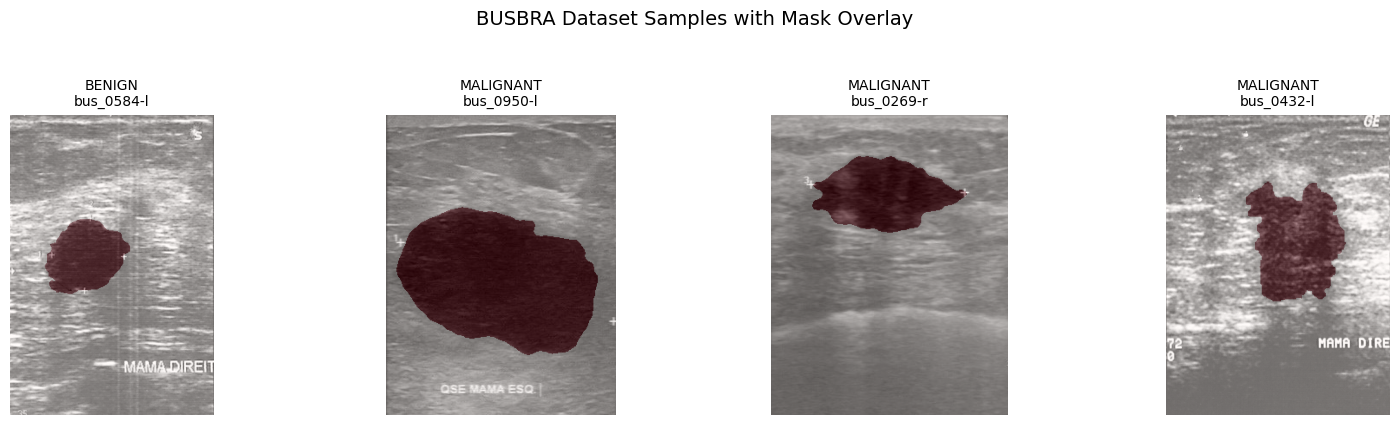

✅ Sample images saved to /content/BreastCancer_ViT/outputs/figures/sample_images.png


In [11]:
# Visualize Sample Images
import cv2
import matplotlib.pyplot as plt
import numpy as np

samples = df.sample(4, random_state=42).to_dict(orient="records")
fig, axs = plt.subplots(1, 4, figsize=(16, 4))

for i, row in enumerate(samples):
    img = cv2.imread(row["image_path"], cv2.IMREAD_GRAYSCALE)
    msk = cv2.imread(row["mask_path"], cv2.IMREAD_GRAYSCALE)

    if img is not None and msk is not None:
        axs[i].imshow(img, cmap="gray")
        axs[i].imshow(msk > 0, alpha=0.35, cmap="Reds")
        axs[i].set_title(f"{row['label'].upper()}\n{row['stem']}", fontsize=10)
        axs[i].axis("off")

plt.suptitle("BUSBRA Dataset Samples with Mask Overlay", fontsize=14, y=1.05)
plt.tight_layout()
plt.savefig(FIGS_DIR / "sample_images.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Sample images saved to", FIGS_DIR / "sample_images.png")


Patients with mixed labels: 0
✅ Splits created:
Train: 1323 samples, 744 patients
Val:   270 samples, 160 patients
Test:  282 samples, 160 patients


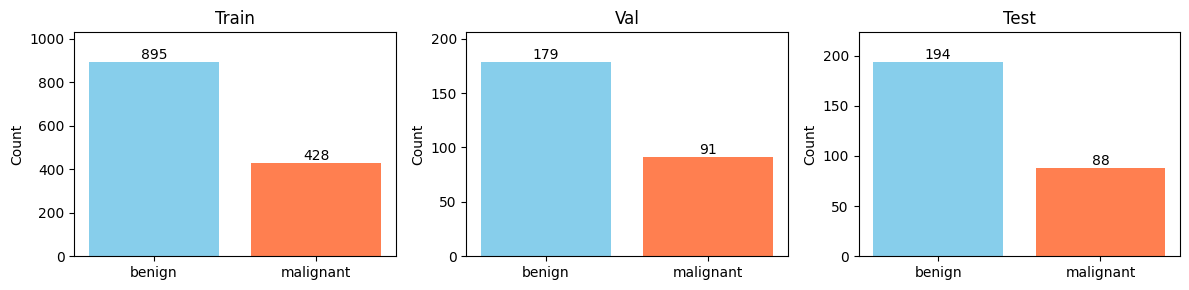

In [12]:
# Create Patient-Wise Train/Val/Test Splits
from sklearn.model_selection import StratifiedShuffleSplit

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Get one label per patient (mode)
patient_labels = df.groupby("patient_id")["label"].agg(lambda s: s.mode()[0]).reset_index()
patient_labels.columns = ["patient_id", "pt_label"]

# Check for mixed labels
mixed = df.groupby("patient_id")["label"].nunique()
num_mixed = (mixed > 1).sum()
print(f"Patients with mixed labels: {num_mixed}")

# 70/15/15 split at patient level (stratified)
sss1 = StratifiedShuffleSplit(n_splits=1, test_size=0.30, random_state=SEED)
train_idx, temp_idx = next(sss1.split(patient_labels["patient_id"], patient_labels["pt_label"]))
train_pts = patient_labels.iloc[train_idx]["patient_id"].values
temp_pts = patient_labels.iloc[temp_idx]["patient_id"].values

# Split temp into val/test (50/50 of temp = 15/15 overall)
pt_temp = patient_labels.iloc[temp_idx].reset_index(drop=True)
sss2 = StratifiedShuffleSplit(n_splits=1, test_size=0.50, random_state=SEED)
val_idx, test_idx = next(sss2.split(pt_temp["patient_id"], pt_temp["pt_label"]))
val_pts = pt_temp.iloc[val_idx]["patient_id"].values
test_pts = pt_temp.iloc[test_idx]["patient_id"].values

# Map back to full dataframe
train_df = df[df["patient_id"].isin(train_pts)].reset_index(drop=True)
val_df = df[df["patient_id"].isin(val_pts)].reset_index(drop=True)
test_df = df[df["patient_id"].isin(test_pts)].reset_index(drop=True)

# Save splits (SPLITS_DIR already defined in setup cell)
train_df.to_csv(SPLITS_DIR / "train.csv", index=False)
val_df.to_csv(SPLITS_DIR / "val.csv", index=False)
test_df.to_csv(SPLITS_DIR / "test.csv", index=False)

print("✅ Splits created:")
print(f"Train: {len(train_df)} samples, {len(train_pts)} patients")
print(f"Val:   {len(val_df)} samples, {len(val_pts)} patients")
print(f"Test:  {len(test_df)} samples, {len(test_pts)} patients")

# Visualize splits
fig, axs = plt.subplots(1, 3, figsize=(12, 3))
for ax, d, n in zip(axs, [train_df, val_df, test_df], ["Train", "Val", "Test"]):
    vc = d["label"].value_counts().sort_index()
    ax.bar(vc.index, vc.values, color=["skyblue", "coral"])
    ax.set_title(n)
    ax.set_ylabel("Count")
    ax.set_ylim(0, max(vc.values) * 1.15)
    for i, v in enumerate(vc.values):
        ax.text(i, v, str(v), ha="center", va="bottom")
plt.tight_layout()
plt.savefig(FIGS_DIR / "data_splits.png", dpi=150)
plt.show()


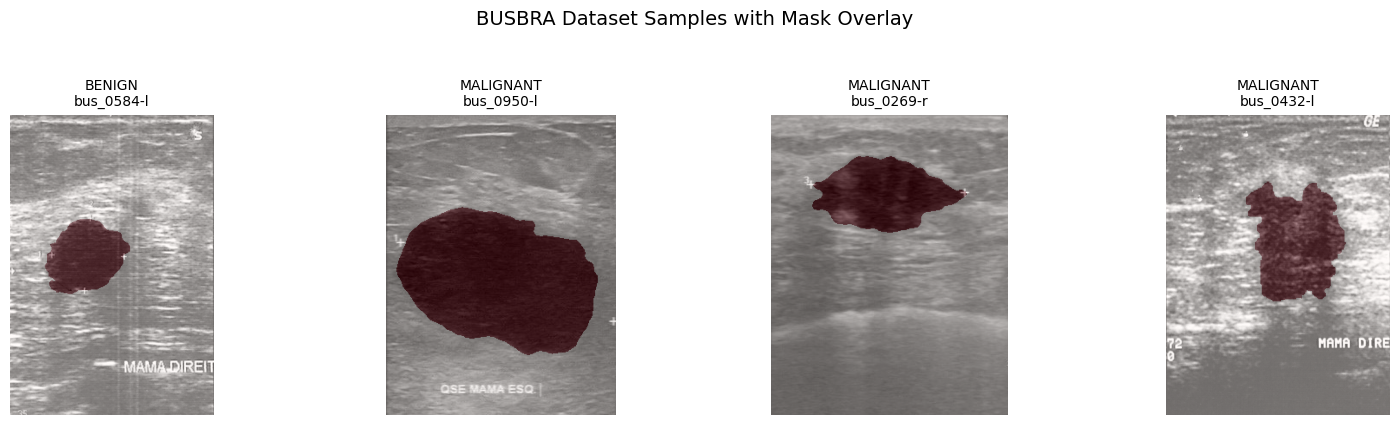

✅ Sample images saved to /content/BreastCancer_ViT/outputs/figures/sample_images.png


In [13]:
# Visualize Sample Images
import cv2
import matplotlib.pyplot as plt
import numpy as np

samples = df.sample(4, random_state=42).to_dict(orient="records")
fig, axs = plt.subplots(1, 4, figsize=(16, 4))

for i, row in enumerate(samples):
    img = cv2.imread(row["image_path"], cv2.IMREAD_GRAYSCALE)
    msk = cv2.imread(row["mask_path"], cv2.IMREAD_GRAYSCALE)

    if img is not None and msk is not None:
        axs[i].imshow(img, cmap="gray")
        axs[i].imshow(msk > 0, alpha=0.35, cmap="Reds")
        axs[i].set_title(f"{row['label'].upper()}\n{row['stem']}", fontsize=10)
        axs[i].axis("off")

plt.suptitle("BUSBRA Dataset Samples with Mask Overlay", fontsize=14, y=1.05)
plt.tight_layout()
plt.savefig(FIGS_DIR / "sample_images.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Sample images saved to", FIGS_DIR / "sample_images.png")


In [14]:
# Data Preprocessing and Augmentation
import albumentations as A
from albumentations.pytorch import ToTensorV2

IMG_SIZE = 224  # ViT standard input size

# Per-image z-score normalization
def zscore_normalize(img):
    """Z-score normalization"""
    mean = img.mean()
    std = img.std() + 1e-6
    return (img - mean) / std

# Training augmentations
train_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.Rotate(limit=15, p=0.5),
    A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.1, rotate_limit=10, p=0.5),
    A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.5),
    A.CLAHE(clip_limit=2.0, tile_grid_size=(8, 8), p=0.5),
    A.GaussNoise(var_limit=(10.0, 50.0), p=0.3),
    A.RandomGamma(gamma_limit=(80, 120), p=0.5),
])

# Validation/Test transforms (no augmentation)
val_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
])

print("✅ Transforms defined")
print(f"Image size: {IMG_SIZE}x{IMG_SIZE}")


✅ Transforms defined
Image size: 224x224


/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)
/tmp/ipython-input-2576051431.py:23: UserWarning: Argument(s) 'var_limit' are not valid for transform GaussNoise
  A.GaussNoise(var_limit=(10.0, 50.0), p=0.3),


✅ Datasets and DataLoaders created
Train batches: 83
Val batches: 17
Test batches: 18


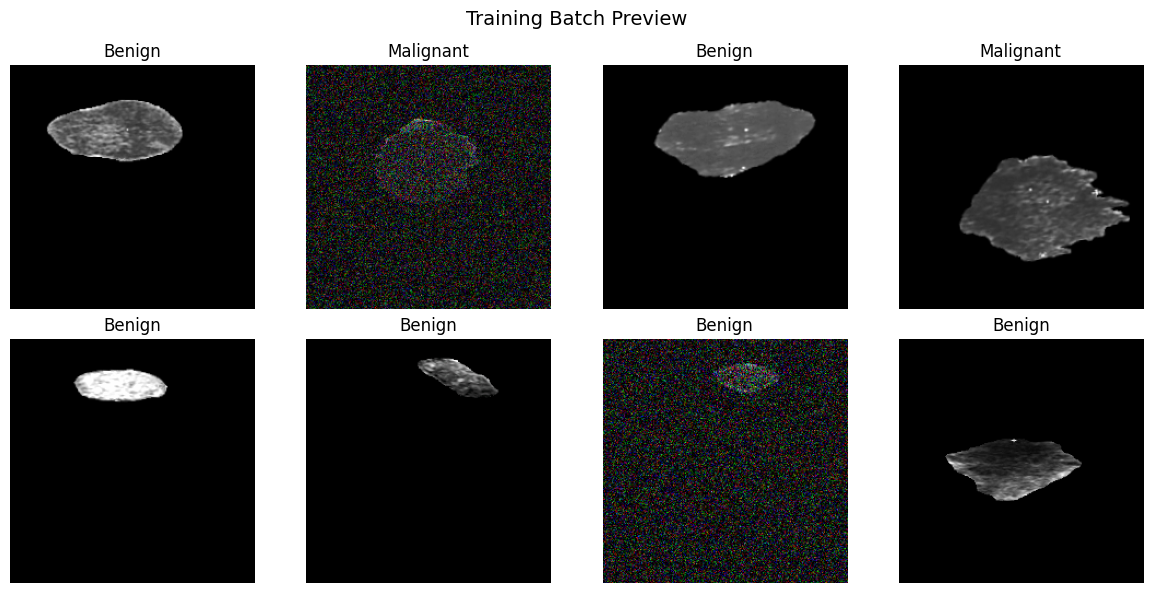

In [15]:
# Dataset Class for PyTorch
from torch.utils.data import Dataset, DataLoader
import torch

class BreastCancerDataset(Dataset):
    """Dataset class for breast cancer ultrasound images"""

    def __init__(self, dataframe, transform=None, use_mask=True):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform
        self.use_mask = use_mask
        self.label_map = {"benign": 0, "malignant": 1}

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        # Load image
        img = cv2.imread(row["image_path"], cv2.IMREAD_GRAYSCALE)
        if img is None:
            raise ValueError(f"Could not load image: {row['image_path']}")

        # Optionally apply mask
        if self.use_mask and pd.notna(row.get("mask_path")):
            mask = cv2.imread(row["mask_path"], cv2.IMREAD_GRAYSCALE)
            if mask is not None:
                img = cv2.bitwise_and(img, img, mask=(mask > 0).astype(np.uint8))

        # Convert to 3-channel (ViT expects RGB)
        img = np.stack([img, img, img], axis=-1)

        # Apply transforms
        if self.transform:
            transformed = self.transform(image=img)
            img = transformed["image"]

        # Normalize
        img = img.astype(np.float32) / 255.0
        img = zscore_normalize(img)

        # Convert to tensor
        img = torch.from_numpy(img).permute(2, 0, 1).float()

        # Get label
        label = self.label_map[row["label"].lower()]
        label = torch.tensor(label, dtype=torch.long)

        return img, label

# Create dataloaders
BATCH_SIZE = 16
NUM_WORKERS = 2 if os.name != 'nt' else 0  # Windows compatibility

train_dataset = BreastCancerDataset(train_df, transform=train_transform, use_mask=True)
val_dataset = BreastCancerDataset(val_df, transform=val_transform, use_mask=True)
test_dataset = BreastCancerDataset(test_df, transform=val_transform, use_mask=True)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True if torch.cuda.is_available() else False
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True if torch.cuda.is_available() else False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True if torch.cuda.is_available() else False
)

print("✅ Datasets and DataLoaders created")
print(f"Train batches: {len(train_loader)}")
print(f"Val batches: {len(val_loader)}")
print(f"Test batches: {len(test_loader)}")

# Visualize a batch
imgs, labels = next(iter(train_loader))
fig, axs = plt.subplots(2, 4, figsize=(12, 6))
for i in range(min(8, len(imgs))):
    ax = axs[i // 4, i % 4]
    img_np = imgs[i].permute(1, 2, 0).numpy()
    img_np = (img_np - img_np.min()) / (img_np.max() - img_np.min() + 1e-6)
    ax.imshow(img_np, cmap="gray")
    ax.set_title("Benign" if labels[i] == 0 else "Malignant")
    ax.axis("off")
plt.suptitle("Training Batch Preview", fontsize=14)
plt.tight_layout()
plt.savefig(FIGS_DIR / "batch_preview.png", dpi=150)
plt.show()


In [16]:
# Vision Transformer Model Setup
import timm

# ViT model configurations to try
VIT_MODELS = {
    "vit_base_patch16_224": "vit_base_patch16_224",
    "vit_large_patch16_224": "vit_large_patch16_224",
    "vit_small_patch16_224": "vit_small_patch16_224",
    "deit_base_patch16_224": "deit_base_distilled_patch16_224",
}

def create_vit_model(model_name, num_classes=2, pretrained=True):
    """Create a Vision Transformer model"""
    try:
        model = timm.create_model(
            model_name,
            pretrained=pretrained,
            num_classes=num_classes,
            in_chans=3
        )
        print(f"✅ Created {model_name} with pretrained weights")
        return model
    except Exception as e:
        print(f"⚠️ Error creating {model_name}: {e}")
        # Try without pretrained
        try:
            model = timm.create_model(
                model_name,
                pretrained=False,
                num_classes=num_classes,
                in_chans=3
            )
            print(f"✅ Created {model_name} without pretrained weights")
            return model
        except Exception as e2:
            print(f"❌ Failed to create {model_name}: {e2}")
            return None

# Create the primary model (ViT-Base)
model_name = "vit_base_patch16_224"
model = create_vit_model(model_name, num_classes=2, pretrained=True)

if model is not None:
    model = model.to(device)
    print(f"\n✅ Model loaded on {device}")

    # Count parameters
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Total parameters: {total_params:,}")
    print(f"Trainable parameters: {trainable_params:,}")

    # Test forward pass
    test_input = torch.randn(1, 3, IMG_SIZE, IMG_SIZE).to(device)
    with torch.no_grad():
        test_output = model(test_input)
    print(f"✅ Test forward pass successful. Output shape: {test_output.shape}")
else:
    raise RuntimeError("Failed to create model")


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

✅ Created vit_base_patch16_224 with pretrained weights

✅ Model loaded on cpu
Total parameters: 85,800,194
Trainable parameters: 85,800,194
✅ Test forward pass successful. Output shape: torch.Size([1, 2])


In [17]:
# Training Setup
import torch.nn as nn
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR, ReduceLROnPlateau
from tqdm import tqdm
import time

# Loss function
criterion = nn.CrossEntropyLoss()

# Optimizer
LEARNING_RATE = 2e-5
WEIGHT_DECAY = 1e-4
optimizer = AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

# Learning rate scheduler
EPOCHS = 50
scheduler = CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)

# Mixed precision training
scaler = torch.cuda.amp.GradScaler(enabled=torch.cuda.is_available())

# Training history
history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": [],
    "val_f1": [],
    "val_precision": [],
    "val_recall": []
}

print("✅ Training setup complete")
print(f"Learning rate: {LEARNING_RATE}")
print(f"Epochs: {EPOCHS}")
print(f"Batch size: {BATCH_SIZE}")


✅ Training setup complete
Learning rate: 2e-05
Epochs: 50
Batch size: 16


/tmp/ipython-input-2852749893.py:21: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=torch.cuda.is_available())


In [18]:
# Training and Validation Functions
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

def train_epoch(model, loader, criterion, optimizer, scaler, device):
    """Train for one epoch"""
    model.train()
    running_loss = 0.0
    all_preds = []
    all_labels = []

    pbar = tqdm(loader, desc="Training")
    for images, labels in pbar:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()

        with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):
            outputs = model(images)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item()
        preds = outputs.argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.cpu().numpy())

        pbar.set_postfix({"loss": f"{loss.item():.4f}"})

    avg_loss = running_loss / len(loader)
    acc = accuracy_score(all_labels, all_preds)

    return avg_loss, acc

def validate(model, loader, criterion, device):
    """Validate the model"""
    model.eval()
    running_loss = 0.0
    all_preds = []
    all_labels = []
    all_probs = []

    with torch.no_grad():
        for images, labels in tqdm(loader, desc="Validating"):
            images, labels = images.to(device), labels.to(device)

            with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):
                outputs = model(images)
                loss = criterion(outputs, labels)

            running_loss += loss.item()
            probs = torch.softmax(outputs, dim=1).cpu().numpy()
            preds = outputs.argmax(dim=1).cpu().numpy()

            all_preds.extend(preds)
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs[:, 1])  # Probability of malignant

    avg_loss = running_loss / len(loader)
    acc = accuracy_score(all_labels, all_preds)
    prec = precision_score(all_labels, all_preds, average="binary", zero_division=0)
    rec = recall_score(all_labels, all_preds, average="binary", zero_division=0)
    f1 = f1_score(all_labels, all_preds, average="binary", zero_division=0)

    return avg_loss, acc, prec, rec, f1, all_probs

print("✅ Training functions defined")


✅ Training functions defined


In [ ]:
# Training Loop
best_val_acc = 0.0
best_val_f1 = 0.0
patience = 10
no_improve = 0
best_model_path = CHECKPOINT_DIR / "best_vit_model.pth"

print("🚀 Starting training...\n")

for epoch in range(1, EPOCHS + 1):
    start_time = time.time()

    # Train
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, scaler, device)

    # Validate
    val_loss, val_acc, val_prec, val_rec, val_f1, _ = validate(model, val_loader, criterion, device)

    # Update learning rate
    scheduler.step()
    current_lr = optimizer.param_groups[0]["lr"]

    # Save history
    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    history["val_f1"].append(val_f1)
    history["val_precision"].append(val_prec)
    history["val_recall"].append(val_rec)

    # Print progress
    elapsed = time.time() - start_time
    print(f"Epoch {epoch:3d}/{EPOCHS} | "
          f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} | "
          f"Val F1: {val_f1:.4f} | LR: {current_lr:.2e} | Time: {elapsed:.1f}s")

    # Save best model (based on F1 score)
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        best_val_acc = val_acc
        torch.save({
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "val_acc": val_acc,
            "val_f1": val_f1,
            "history": history
        }, best_model_path)
        no_improve = 0
        print(f"  ✅ Best model saved! (F1: {val_f1:.4f}, Acc: {val_acc:.4f})")
    else:
        no_improve += 1

    # Early stopping
    if no_improve >= patience:
        print(f"\n⏹️  Early stopping triggered after {epoch} epochs")
        break

print(f"\n✅ Training completed!")
print(f"Best validation F1: {best_val_f1:.4f}")
print(f"Best validation Accuracy: {best_val_acc:.4f}")
print(f"Model saved to: {best_model_path}")


🚀 Starting training...



Training:   0%|          | 0/83 [00:00<?, ?it/s]/tmp/ipython-input-3983282141.py:17: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):
Validating:   0%|          | 0/17 [00:00<?, ?it/s]/tmp/ipython-input-3983282141.py:49: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):
Validating: 100%|██████████| 17/17 [02:58<00:00, 10.49s/it]


Epoch   1/50 | Train Loss: 0.4529 | Train Acc: 0.7974 | Val Loss: 0.5940 | Val Acc: 0.7556 | Val F1: 0.4407 | LR: 2.00e-05 | Time: 2877.3s
  ✅ Best model saved! (F1: 0.4407, Acc: 0.7556)


Training:   0%|          | 0/83 [00:00<?, ?it/s]/tmp/ipython-input-3983282141.py:17: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):
Training:  18%|█▊        | 15/83 [08:16<37:03, 32.70s/it, loss=0.5091]

✅ Best model loaded

📊 Evaluating on test set...


Validating:   0%|          | 0/18 [00:00<?, ?it/s]/tmp/ipython-input-3282456108.py:49: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):
Validating: 100%|██████████| 18/18 [00:02<00:00,  8.98it/s]


TEST SET RESULTS
Accuracy:  0.8652
Precision: 0.7660
Recall:    0.8182
F1 Score:  0.7912



Confusion Matrix:
[[172  22]
 [ 16  72]]


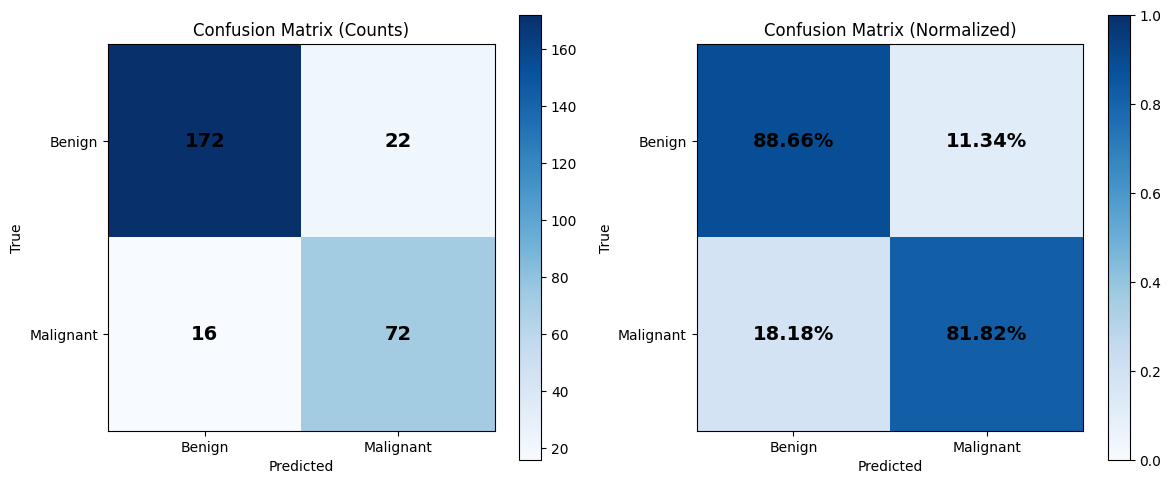

In [ ]:
# Load Best Model and Evaluate on Test Set
# Load the best model
checkpoint = torch.load(best_model_path, map_location=device)
model.load_state_dict(checkpoint["model_state_dict"])
print("✅ Best model loaded")

# Evaluate on test set
print("\n📊 Evaluating on test set...")
test_loss, test_acc, test_prec, test_rec, test_f1, test_probs = validate(
    model, test_loader, criterion, device
)

print("\n" + "="*60)
print("TEST SET RESULTS")
print("="*60)
print(f"Accuracy:  {test_acc:.4f}")
print(f"Precision: {test_prec:.4f}")
print(f"Recall:    {test_rec:.4f}")
print(f"F1 Score:  {test_f1:.4f}")
print("="*60)

# Get predictions for confusion matrix
model.eval()
all_test_preds = []
all_test_labels = []
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        preds = outputs.argmax(dim=1).cpu().numpy()
        all_test_preds.extend(preds)
        all_test_labels.extend(labels.cpu().numpy())

# Confusion Matrix
cm = confusion_matrix(all_test_labels, all_test_preds)
print("\nConfusion Matrix:")
print(cm)

# Plot confusion matrix
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Counts
im1 = ax1.imshow(cm, cmap="Blues", interpolation="nearest")
ax1.set_title("Confusion Matrix (Counts)")
ax1.set_xticks([0, 1])
ax1.set_yticks([0, 1])
ax1.set_xticklabels(["Benign", "Malignant"])
ax1.set_yticklabels(["Benign", "Malignant"])
ax1.set_xlabel("Predicted")
ax1.set_ylabel("True")
for i in range(2):
    for j in range(2):
        ax1.text(j, i, str(cm[i, j]), ha="center", va="center", fontsize=14, fontweight="bold")
plt.colorbar(im1, ax=ax1)

# Normalized
cm_norm = cm.astype("float") / cm.sum(axis=1, keepdims=True)
im2 = ax2.imshow(cm_norm, cmap="Blues", vmin=0, vmax=1, interpolation="nearest")
ax2.set_title("Confusion Matrix (Normalized)")
ax2.set_xticks([0, 1])
ax2.set_yticks([0, 1])
ax2.set_xticklabels(["Benign", "Malignant"])
ax2.set_yticklabels(["Benign", "Malignant"])
ax2.set_xlabel("Predicted")
ax2.set_ylabel("True")
for i in range(2):
    for j in range(2):
        ax2.text(j, i, f"{cm_norm[i, j]:.2%}", ha="center", va="center", fontsize=14, fontweight="bold")
plt.colorbar(im2, ax=ax2)

plt.tight_layout()
plt.savefig(FIGS_DIR / "confusion_matrix.png", dpi=150)
plt.show()


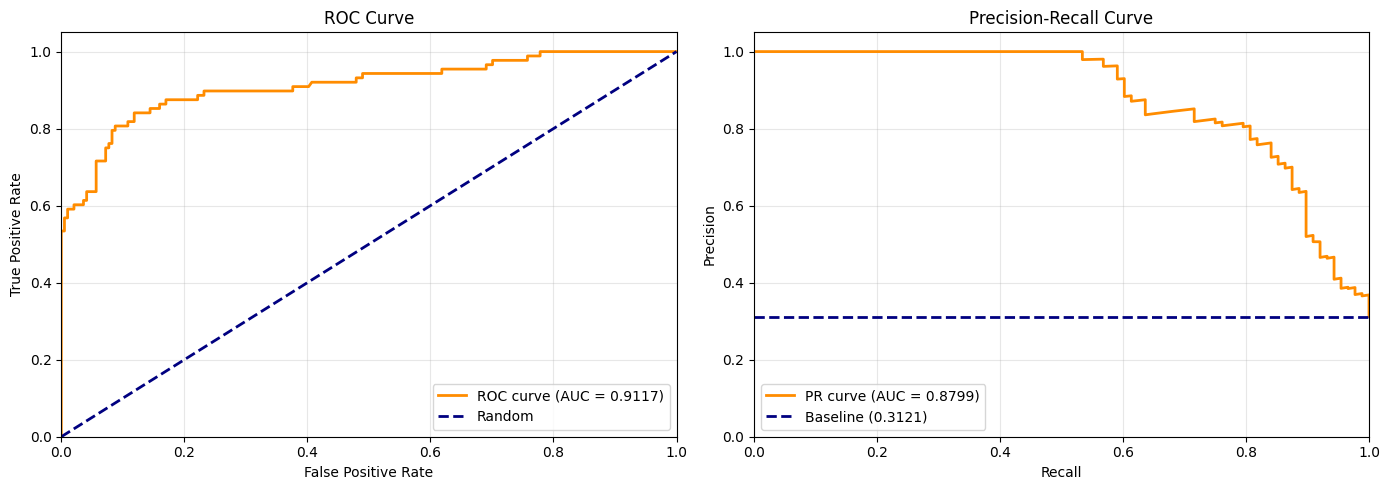

ROC AUC: 0.9117
PR AUC: 0.8799

✅ Metrics saved to /content/BreastCancer_ViT/outputs/results/test_metrics.csv


In [ ]:
# ROC Curve and Precision-Recall Curve
from sklearn.metrics import roc_curve, auc, precision_recall_curve

# Get true labels and probabilities
test_labels_array = np.array(all_test_labels)
test_probs_array = np.array(test_probs)

# ROC Curve
fpr, tpr, _ = roc_curve(test_labels_array, test_probs_array)
roc_auc = auc(fpr, tpr)

# Precision-Recall Curve
precision, recall, _ = precision_recall_curve(test_labels_array, test_probs_array)
pr_auc = auc(recall, precision)

# Plot both curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# ROC Curve
ax1.plot(fpr, tpr, color="darkorange", lw=2, label=f"ROC curve (AUC = {roc_auc:.4f})")
ax1.plot([0, 1], [0, 1], color="navy", lw=2, linestyle="--", label="Random")
ax1.set_xlim([0.0, 1.0])
ax1.set_ylim([0.0, 1.05])
ax1.set_xlabel("False Positive Rate")
ax1.set_ylabel("True Positive Rate")
ax1.set_title("ROC Curve")
ax1.legend(loc="lower right")
ax1.grid(alpha=0.3)

# Precision-Recall Curve
ax2.plot(recall, precision, color="darkorange", lw=2, label=f"PR curve (AUC = {pr_auc:.4f})")
baseline = sum(test_labels_array) / len(test_labels_array)
ax2.axhline(y=baseline, color="navy", lw=2, linestyle="--", label=f"Baseline ({baseline:.4f})")
ax2.set_xlim([0.0, 1.0])
ax2.set_ylim([0.0, 1.05])
ax2.set_xlabel("Recall")
ax2.set_ylabel("Precision")
ax2.set_title("Precision-Recall Curve")
ax2.legend(loc="lower left")
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(FIGS_DIR / "roc_pr_curves.png", dpi=150)
plt.show()

print(f"ROC AUC: {roc_auc:.4f}")
print(f"PR AUC: {pr_auc:.4f}")

# Save metrics to CSV
metrics_df = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1 Score", "ROC AUC", "PR AUC"],
    "Value": [test_acc, test_prec, test_rec, test_f1, roc_auc, pr_auc]
})
metrics_df.to_csv(RESULTS_DIR / "test_metrics.csv", index=False)
print("\n✅ Metrics saved to", RESULTS_DIR / "test_metrics.csv")


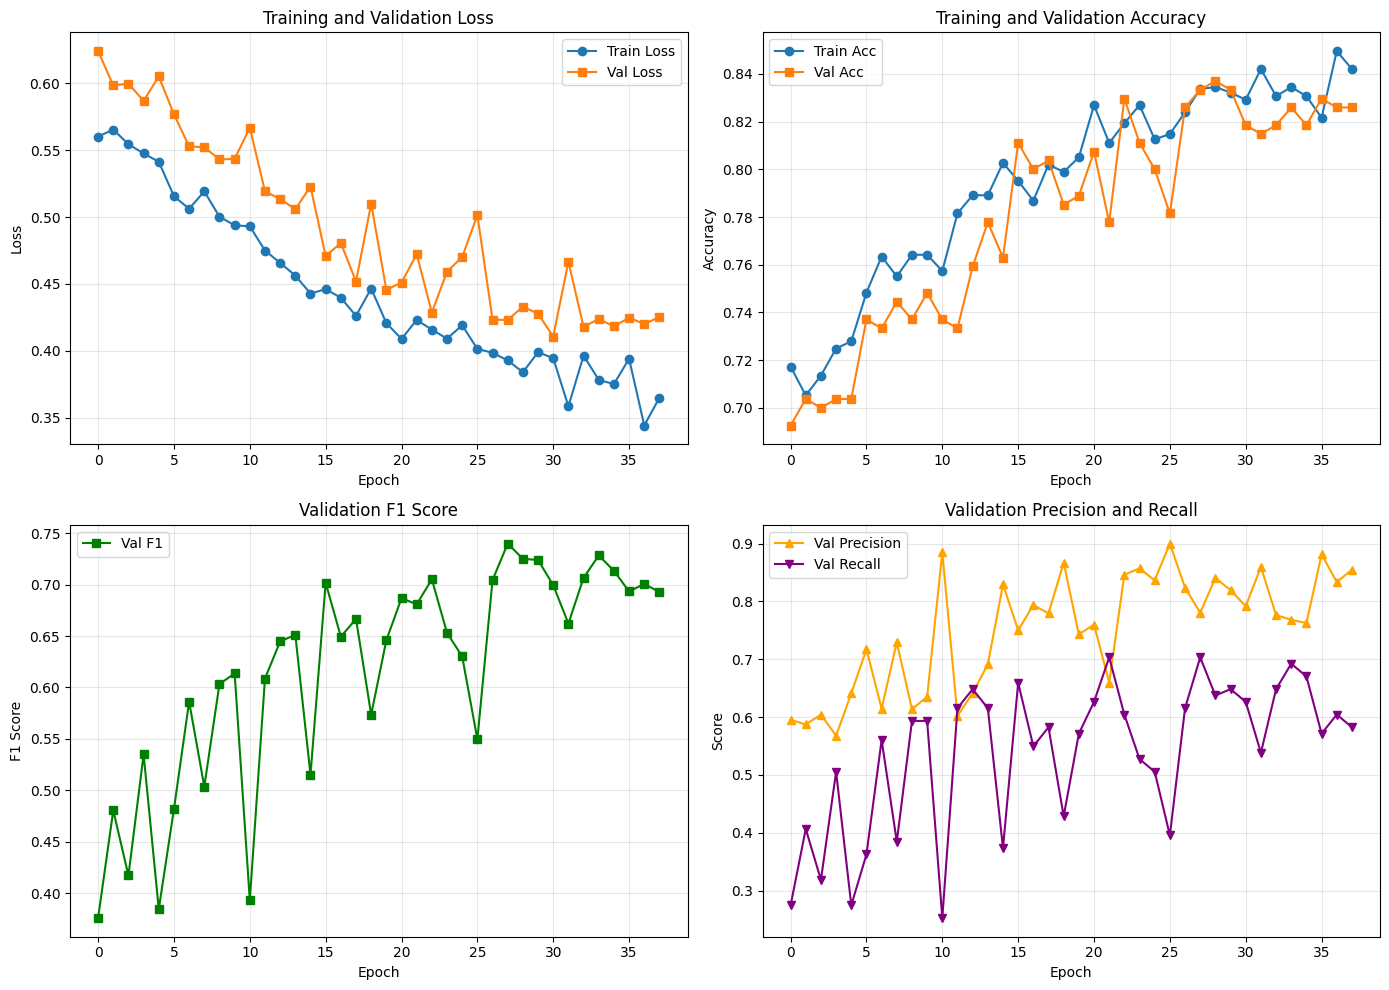

✅ Training history saved


In [ ]:
# Training History Visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Loss
axes[0, 0].plot(history["train_loss"], label="Train Loss", marker="o")
axes[0, 0].plot(history["val_loss"], label="Val Loss", marker="s")
axes[0, 0].set_xlabel("Epoch")
axes[0, 0].set_ylabel("Loss")
axes[0, 0].set_title("Training and Validation Loss")
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# Accuracy
axes[0, 1].plot(history["train_acc"], label="Train Acc", marker="o")
axes[0, 1].plot(history["val_acc"], label="Val Acc", marker="s")
axes[0, 1].set_xlabel("Epoch")
axes[0, 1].set_ylabel("Accuracy")
axes[0, 1].set_title("Training and Validation Accuracy")
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# F1 Score
axes[1, 0].plot(history["val_f1"], label="Val F1", marker="s", color="green")
axes[1, 0].set_xlabel("Epoch")
axes[1, 0].set_ylabel("F1 Score")
axes[1, 0].set_title("Validation F1 Score")
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

# Precision and Recall
axes[1, 1].plot(history["val_precision"], label="Val Precision", marker="^", color="orange")
axes[1, 1].plot(history["val_recall"], label="Val Recall", marker="v", color="purple")
axes[1, 1].set_xlabel("Epoch")
axes[1, 1].set_ylabel("Score")
axes[1, 1].set_title("Validation Precision and Recall")
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(FIGS_DIR / "training_history.png", dpi=150)
plt.show()

# Save history
history_df = pd.DataFrame(history)
history_df.to_csv(RESULTS_DIR / "training_history.csv", index=False)
print("✅ Training history saved")


In [ ]:
# AUTOMATIC INFERENCE FUNCTION
# This function automatically generates output for any input image

def predict_image(image_path, model, device, transform=None, use_mask=True, mask_path=None):
    """
    Predict classification for a single image

    Args:
        image_path: Path to the input image
        model: Trained model
        device: Device to run inference on
        transform: Image transform (optional)
        use_mask: Whether to apply mask (if mask_path provided)
        mask_path: Path to mask image (optional)

    Returns:
        dict: Prediction results with probabilities and class
    """
    model.eval()

    # Load image
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise ValueError(f"Could not load image: {image_path}")

    # Apply mask if provided
    if use_mask and mask_path is not None:
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        if mask is not None:
            img = cv2.bitwise_and(img, img, mask=(mask > 0).astype(np.uint8))

    # Convert to 3-channel
    img = np.stack([img, img, img], axis=-1)

    # Apply transform
    if transform:
        transformed = transform(image=img)
        img = transformed["image"]
    else:
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

    # Normalize
    img = img.astype(np.float32) / 255.0
    img = zscore_normalize(img)

    # Convert to tensor
    img_tensor = torch.from_numpy(img).permute(2, 0, 1).float().unsqueeze(0).to(device)

    # Predict
    with torch.no_grad():
        outputs = model(img_tensor)
        probs = torch.softmax(outputs, dim=1)[0].cpu().numpy()
        pred_class = outputs.argmax(dim=1)[0].item()

    class_names = ["Benign", "Malignant"]
    result = {
        "predicted_class": class_names[pred_class],
        "benign_probability": float(probs[0]),
        "malignant_probability": float(probs[1]),
        "confidence": float(max(probs))
    }

    return result

# Test the inference function
print("✅ Inference function created")
print("\nTesting inference on a sample image...")

# Test on a sample from test set
sample_row = test_df.iloc[0]
result = predict_image(
    sample_row["image_path"],
    model,
    device,
    transform=val_transform,
    use_mask=True,
    mask_path=sample_row["mask_path"]
)

print(f"\nImage: {sample_row['stem']}")
print(f"True Label: {sample_row['label'].upper()}")
print(f"Predicted: {result['predicted_class']}")
print(f"Benign Probability: {result['benign_probability']:.4f}")
print(f"Malignant Probability: {result['malignant_probability']:.4f}")
print(f"Confidence: {result['confidence']:.4f}")


✅ Inference function created

Testing inference on a sample image...

Image: bus_0014-s
True Label: MALIGNANT
Predicted: Benign
Benign Probability: 0.8512
Malignant Probability: 0.1488
Confidence: 0.8512


In [ ]:
# Batch Inference Function (for multiple images)
def predict_batch(image_paths, model, device, transform=None, mask_paths=None, use_mask=True):
    """
    Predict classification for multiple images

    Args:
        image_paths: List of paths to input images
        model: Trained model
        device: Device to run inference on
        transform: Image transform (optional)
        mask_paths: List of mask paths (optional, same length as image_paths)
        use_mask: Whether to apply masks

    Returns:
        list: List of prediction results
    """
    results = []
    for i, img_path in enumerate(image_paths):
        mask_path = mask_paths[i] if mask_paths else None
        try:
            result = predict_image(img_path, model, device, transform, use_mask, mask_path)
            result["image_path"] = img_path
            results.append(result)
        except Exception as e:
            print(f"Error processing {img_path}: {e}")
            results.append({"image_path": img_path, "error": str(e)})
    return results

# Example: Predict on all test images
print("📊 Running batch inference on test set...")
test_image_paths = test_df["image_path"].tolist()
test_mask_paths = test_df["mask_path"].tolist()

batch_results = predict_batch(
    test_image_paths,
    model,
    device,
    transform=val_transform,
    mask_paths=test_mask_paths,
    use_mask=True
)

# Save results
results_df = pd.DataFrame(batch_results)
results_df.to_csv(RESULTS_DIR / "batch_predictions.csv", index=False)
print(f"✅ Batch predictions saved to {RESULTS_DIR / 'batch_predictions.csv'}")
print(f"Processed {len(batch_results)} images")


📊 Running batch inference on test set...
✅ Batch predictions saved to /content/BreastCancer_ViT/outputs/results/batch_predictions.csv
Processed 282 images


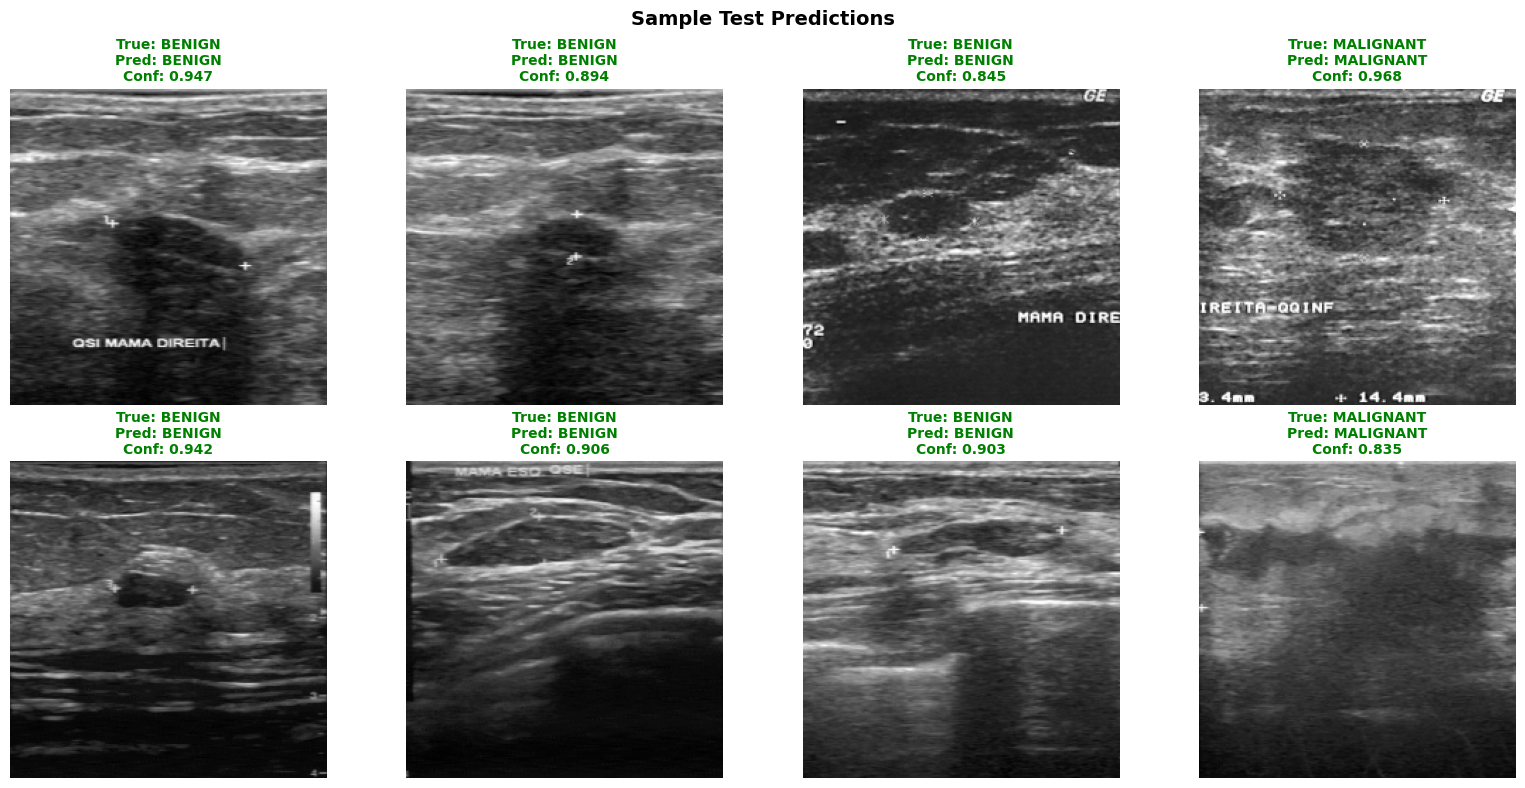

✅ Sample predictions visualization saved


In [ ]:
# Visualize Predictions on Sample Images
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
sample_indices = np.random.choice(len(test_df), 8, replace=False)

for idx, ax in enumerate(axes.flat):
    row_idx = sample_indices[idx]
    row = test_df.iloc[row_idx]

    # Load and display image
    img = cv2.imread(row["image_path"], cv2.IMREAD_GRAYSCALE)
    img_resized = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

    # Get prediction
    result = predict_image(
        row["image_path"],
        model,
        device,
        transform=val_transform,
        use_mask=True,
        mask_path=row["mask_path"]
    )

    # Display
    ax.imshow(img_resized, cmap="gray")
    true_label = row["label"].upper()
    pred_label = result["predicted_class"].upper()
    confidence = result["confidence"]

    # Color: green if correct, red if wrong
    color = "green" if true_label == pred_label else "red"
    title = f"True: {true_label}\nPred: {pred_label}\nConf: {confidence:.3f}"
    ax.set_title(title, color=color, fontsize=10, fontweight="bold")
    ax.axis("off")

plt.suptitle("Sample Test Predictions", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(FIGS_DIR / "sample_predictions.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Sample predictions visualization saved")


In [ ]:
# Step 16: 🧪 Interactive Image Testing with Grad-CAM
import ipywidgets as widgets
from IPython.display import display, clear_output
import os
import numpy as np
import matplotlib.pyplot as plt
import cv2

print("🎯 INTERACTIVE IMAGE TESTING WITH Grad-CAM")
print("="*60)

# ==============================
# ✅ SETUP MODEL + LABELS HERE
# ==============================
# Load your trained model (this notebook uses a PyTorch model)
# Ensure your PyTorch model 'model' and 'device' are available from previous cells.

class_labels = ['Benign', 'Malignant']  # Updated to match the trained model's output classes

# -------------------------------
# WIDGETS
# -------------------------------

# Function to get image files from the test_df
def get_test_image_paths(test_dataframe):
    if 'image_path' in test_dataframe.columns:
        return test_dataframe['image_path'].tolist()
    return []

test_image_paths_list = get_test_image_paths(test_df)

# Dropdown for image selection (using test set images)
image_dropdown = widgets.Dropdown(
    options=test_image_paths_list,
    description='🖼️ Select image:',
    disabled=False,
    layout=widgets.Layout(width='80%')
)

# Status label
status_label = widgets.Label(value=f"✅ Found {len(test_image_paths_list)} test images")

# -------------------------------
# GRAD-CAM FUNCTIONS (THESE ARE FOR TENSORFLOW/KERAS AND WILL NOT WORK WITH PYTORCH MODEL)
# -------------------------------
# To implement Grad-CAM for a PyTorch model, this section needs to be rewritten.
def overlay_gradcam(img_path, heatmap, alpha=0.4):
    img = cv2.imread(img_path)
    img = cv2.resize(img, (224, 224))
    heatmap = cv2.resize(heatmap, (img.shape[1], img.shape[0]))
    heatmap = np.uint8(255 * heatmap)
    heatmap_color = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
    superimposed_img = cv2.addWeighted(img, 1-alpha, heatmap_color, alpha, 0)
    superimposed_img = cv2.cvtColor(superimposed_img, cv2.COLOR_BGR2RGB)
    return superimposed_img

# -------------------------------
# ANALYSIS BUTTON
# -------------------------------
analyze_button = widgets.Button(
    description='🚀 Run Analysis',
    button_style='success',
    tooltip='Click to analyze selected image',
    icon='search'
)

output = widgets.Output()

def analyze_image(b):
    with output:
        clear_output(wait=True)
        full_image_path = image_dropdown.value # Path now directly from test_df
        if not os.path.exists(full_image_path):
            print("❌ Image not found!")
            return
        print("🔍 Analyzing image...")
        try:
            # Get the corresponding mask path from test_df
            sample_row = test_df[test_df['image_path'] == full_image_path].iloc[0]
            mask_path = sample_row['mask_path']

            # Using the predict_image function from earlier cells for prediction
            prediction_result = predict_image(
                full_image_path,
                model, # Your PyTorch model
                device,
                transform=val_transform, # Your PyTorch val_transform
                use_mask=True, # Adjust if you want to use masks during interactive testing
                mask_path=mask_path
            )

            predicted_label = prediction_result['predicted_class']
            confidence = prediction_result['confidence'] * 100
            probs_dict = {
                'Benign': prediction_result['benign_probability'],
                'Malignant': prediction_result['malignant_probability']
            }

            # Grad-CAM requires specific PyTorch implementation
            input_img = cv2.imread(full_image_path)
            input_img = cv2.cvtColor(input_img, cv2.COLOR_BGR2RGB)
            input_img = cv2.resize(input_img, (IMG_SIZE, IMG_SIZE))

            fig, ax1 = plt.subplots(1, 1, figsize=(7,6))
            ax1.imshow(input_img)
            ax1.set_title("INPUT IMAGE", fontsize=14, fontweight='bold')
            ax1.axis('off')

            plt.suptitle(f"Prediction: {predicted_label} ({confidence:.2f}%)", fontsize=16, fontweight='bold', y=1.02)
            plt.tight_layout()
            plt.show()

            # Console output
            print("✅ ANALYSIS COMPLETE!")
            print("="*50)
            print(f"Prediction: {predicted_label}")
            print(f"Confidence: {confidence:.2f}%")
            print(f"Image: {os.path.basename(full_image_path)}")
            print("\nProbabilities:")
            for label, prob in probs_dict.items():
                print(f"  {label}: {prob:.4f}")
            print("="*50)
        except Exception as e:
            print(f"❌ Error: {str(e)}")
            import traceback
            traceback.print_exc()

analyze_button.on_click(analyze_image)

# -------------------------------
# DISPLAY UI
# -------------------------------
display(widgets.HTML("<h4>📋 Testing Instructions:</h4>"))
display(widgets.HTML("<ol style='font-size:14px;'>"
                     "<li>Select an image from the test set dropdown</li>"
                     "<li>Click 'Run Analysis'</li>"
                     "<li>View Prediction</li>"
                     "</ol>"))
display(status_label)
display(image_dropdown)
display(analyze_button)
display(output)


🎯 INTERACTIVE IMAGE TESTING WITH Grad-CAM


HTML(value='<h4>📋 Testing Instructions:</h4>')

HTML(value="<ol style='font-size:14px;'><li>Select an image from the test set dropdown</li><li>Click 'Run Anal…

Label(value='✅ Found 282 test images')

Dropdown(description='🖼️ Select image:', layout=Layout(width='80%'), options=('/content/BUSBRA/Images/bus_0014…

Button(button_style='success', description='🚀 Run Analysis', icon='search', style=ButtonStyle(), tooltip='Clic…

Output()

In [ ]:
# Final Summary Report
print("="*70)
print("BREAST CANCER ULTRASOUND CLASSIFICATION - FINAL REPORT")
print("="*70)
print(f"\nDataset: BUSBRA")
print(f"Model: Vision Transformer (ViT-Base)")
print(f"Image Size: {IMG_SIZE}x{IMG_SIZE}")
print(f"Total Samples: {len(df)}")
print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")

print("\n" + "-"*70)
print("TEST SET PERFORMANCE METRICS")
print("-"*70)
print(f"Accuracy:  {test_acc:.4f} ({test_acc*100:.2f}%)")
print(f"Precision: {test_prec:.4f} ({test_prec*100:.2f}%)")
print(f"Recall:    {test_rec:.4f} ({test_rec*100:.2f}%)")
print(f"F1 Score:  {test_f1:.4f} ({test_f1*100:.2f}%)")
print(f"ROC AUC:   {roc_auc:.4f}")
print(f"PR AUC:    {pr_auc:.4f}")

print("\n" + "-"*70)
print("MODEL INFORMATION")
print("-"*70)
print(f"Total Parameters: {total_params:,}")
print(f"Best Validation F1: {best_val_f1:.4f}")
print(f"Best Validation Accuracy: {best_val_acc:.4f}")

print("\n" + "-"*70)
print("OUTPUT FILES")
print("-"*70)
print(f"Model Checkpoint: {best_model_path}")
print(f"Results Directory: {RESULTS_DIR}")
print(f"Figures Directory: {FIGS_DIR}")
print(f"  - confusion_matrix.png")
print(f"  - roc_pr_curves.png")
print(f"  - training_history.png")
print(f"  - sample_predictions.png")
print(f"  - batch_predictions.csv")
print(f"  - test_metrics.csv")
print(f"  - training_history.csv")

print("\n" + "="*70)
print("✅ ALL ANALYSIS COMPLETE!")
print("="*70)


BREAST CANCER ULTRASOUND CLASSIFICATION - FINAL REPORT

Dataset: BUSBRA
Model: Vision Transformer (ViT-Base)
Image Size: 224x224
Total Samples: 1875
Train: 1323 | Val: 270 | Test: 282

----------------------------------------------------------------------
TEST SET PERFORMANCE METRICS
----------------------------------------------------------------------
Accuracy:  0.8652 (86.52%)
Precision: 0.7660 (76.60%)
Recall:    0.8182 (81.82%)
F1 Score:  0.7912 (79.12%)
ROC AUC:   0.9117
PR AUC:    0.8799

----------------------------------------------------------------------
MODEL INFORMATION
----------------------------------------------------------------------
Total Parameters: 85,800,194
Best Validation F1: 0.7399
Best Validation Accuracy: 0.8333

----------------------------------------------------------------------
OUTPUT FILES
----------------------------------------------------------------------
Model Checkpoint: /content/BreastCancer_ViT/outputs/checkpoints/best_vit_model.pth
Results Dir